# Sensor Monitoring and Anomaly Detection for Industry 4.0

We will create reproducible temperature and vibration readings for three industrial machines. Then we will clean and explore the data, detect changes with six-hour sliding windows, export an anomaly report, and prepare an optional local Tkinter dashboard.

## 1. Setup and Introduction

First, import the allowed libraries, fix the random seed, and create a folder for charts and tables. Every output from this notebook will be saved in that folder.

In [39]:
# Import the libraries used in this project.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use a fixed seed so the simulated data is repeatable.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Create a folder for saved charts and tables.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Set a consistent visual style and palette.
BLUE = "#2878B5"
RED = "#D62728"
DARK = "#17212B"
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15

print("Output folder:", OUTPUT_DIR.resolve())

Output folder: C:\Users\HP\Desktop\vgy\outputs


## 2. Data Generation

We simulate one reading every ten minutes for 30 days on three machines. Daily temperature and vibration patterns have measurement noise; Machine_B develops a gradual drift, and we add occasional spikes, missing sensor values, and duplicate rows.

In [40]:
# Create timestamps and the three machine names.
timestamps = pd.date_range("2025-01-01", periods=30 * 24 * 6, freq="10min")
machine_names = ["Machine_A", "Machine_B", "Machine_C"]
time_number = np.arange(len(timestamps))
hour_of_day = timestamps.hour.to_numpy() + timestamps.minute.to_numpy() / 60
daily_cycle = np.sin(2 * np.pi * (hour_of_day - 6) / 24)
sensor_frames = []

# Generate sensor readings for each machine.
for machine_name in machine_names:
    machine_number = machine_names.index(machine_name)
    temperature_base = 62 + machine_number * 2
    vibration_base = 2.4 + machine_number * 0.25
    temperature = temperature_base + 3.5 * daily_cycle
    temperature = temperature + np.random.normal(0, 0.8, len(timestamps))
    vibration = vibration_base + 0.45 * daily_cycle
    vibration = vibration + np.random.normal(0, 0.18, len(timestamps))

    # Add a gradual temperature and vibration drift to Machine_B.
    if machine_name == "Machine_B":
        drift = np.maximum(time_number - 10 * 24 * 6, 0) / (20 * 24 * 6)
        temperature = temperature + 13 * drift
        vibration = vibration + 2.4 * drift

    # Add a few sudden sensor spikes to each machine.
    spike_positions = np.random.choice(len(timestamps), size=5, replace=False)
    temperature[spike_positions] = temperature[spike_positions] + 18
    vibration[spike_positions] = vibration[spike_positions] + 5

    machine_frame = pd.DataFrame({
        "timestamp": timestamps,
        "machine_id": machine_name,
        "temperature": temperature,
        "vibration": vibration
    })
    sensor_frames.append(machine_frame)

# Combine the machine readings into one raw data table.
raw_data = pd.concat(sensor_frames, ignore_index=True)

# Set about three percent of sensor values to missing.
missing_count = int(len(raw_data) * 2 * 0.03)
missing_rows = np.random.choice(raw_data.index, size=missing_count, replace=False)
missing_columns = np.random.choice(["temperature", "vibration"], size=missing_count)
for row_number, column_name in zip(missing_rows, missing_columns):
    raw_data.loc[row_number, column_name] = np.nan

# Add about one percent duplicate rows and save the raw data.
duplicate_count = int(len(raw_data) * 0.01)
duplicate_rows = raw_data.sample(n=duplicate_count, random_state=RANDOM_SEED)
raw_data = pd.concat([raw_data, duplicate_rows], ignore_index=True)
raw_data.to_csv(OUTPUT_DIR / "sensor_readings_raw.csv", index=False)

print("Raw rows:", len(raw_data))
print("Raw data saved to outputs/sensor_readings_raw.csv")

Raw rows: 13089
Raw data saved to outputs/sensor_readings_raw.csv


## 3. Data Loading

Load the saved CSV instead of relying on the in-memory generator. The preview, shape, and data types help us confirm what is in the file before analysis.

In [41]:
# Load the raw readings and inspect a few rows.
loaded_data = pd.read_csv(OUTPUT_DIR / "sensor_readings_raw.csv")
display(loaded_data.head())
print("Shape:", loaded_data.shape)
print("Data types before cleaning:")
display(loaded_data.dtypes.to_frame(name="data_type"))

,timestamp,machine_id,temperature,vibration
0,2025-01-01 00:00:00,Machine_A,58.897371,1.946423
1,2025-01-01 00:10:00,Machine_A,58.392720,1.931121
2,2025-01-01 00:20:00,Machine_A,59.031469,2.171363
3,2025-01-01 00:30:00,Machine_A,59.748367,1.760048
4,2025-01-01 00:40:00,Machine_A,58.365850,1.819583


Shape: (13089, 4)
Data types before cleaning:


,data_type
timestamp,str
machine_id,str
temperature,float64
vibration,float64


## 4. Data Summary

These summaries describe the sensor ranges and compare machines. We save a compact per-machine table so it can be reused in a slide or report.

In [42]:
# Show temperature and vibration descriptive statistics.
display(loaded_data[["temperature", "vibration"]].describe().round(2))

# Build a slide-ready summary for each machine.
machine_summary = loaded_data.groupby("machine_id").agg(
    temperature_mean=("temperature", "mean"),
    temperature_min=("temperature", "min"),
    temperature_max=("temperature", "max"),
    vibration_mean=("vibration", "mean"),
    vibration_min=("vibration", "min"),
    vibration_max=("vibration", "max"),
    row_count=("timestamp", "size")
).reset_index()
machine_summary = machine_summary.round(2)
display(machine_summary)
machine_summary.to_csv(OUTPUT_DIR / "machine_summary.csv", index=False)

,temperature,vibration
count,12693.00,12696.00
mean,65.47,2.92
std,4.49,0.75
min,56.17,1.29
25%,62.40,2.43
50%,64.89,2.79
75%,68.11,3.23
max,90.41,8.84


,machine_id,temperature_mean,temperature_min,temperature_max,vibration_mean,vibration_min,vibration_max,row_count
0,Machine_A,62.02,56.17,84.17,2.40,1.29,7.64,4359
1,Machine_B,68.35,58.72,90.41,3.46,1.59,8.84,4368
2,Machine_C,66.02,59.80,85.54,2.91,1.92,8.46,4362


## 5. Data Quality and Cleaning

We first count missing values and duplicates. Then we interpolate sensor readings within each machine, remove repeated records, convert timestamps, and sort the readings into time order. Interpolation is reasonable here because readings are frequent and short gaps can be estimated from neighboring measurements.

,missing_values
timestamp,0
machine_id,0
temperature,396
vibration,393


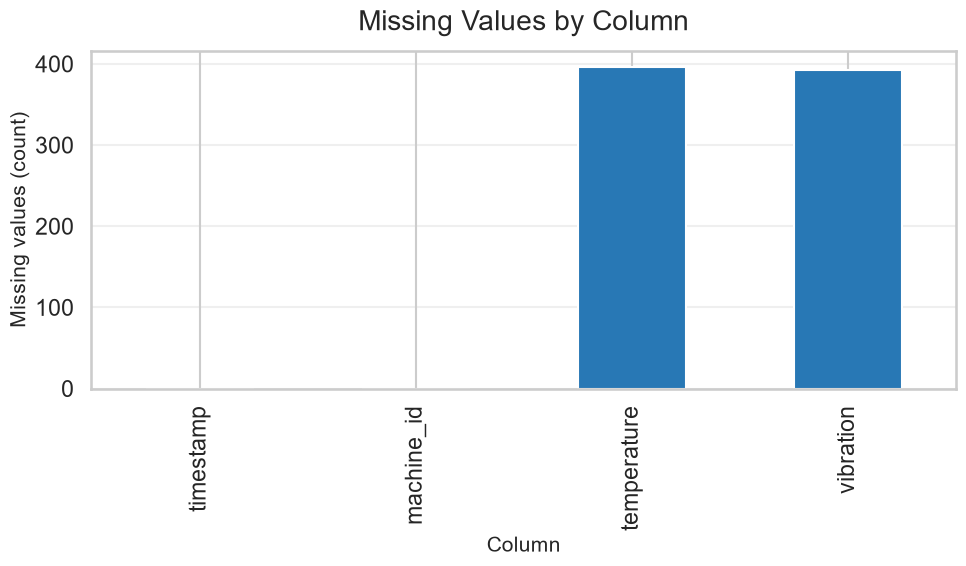

In [43]:
# Record data quality before cleaning and show the missing-value counts.
before_rows = len(loaded_data)
before_missing = int(loaded_data.isna().sum().sum())
before_duplicates = int(loaded_data.duplicated().sum())
missing_by_column = loaded_data.isna().sum()
display(missing_by_column.rename("missing_values").to_frame())

# Chart the number of missing values in each column.
fig, ax = plt.subplots(figsize=(10, 6))
missing_by_column.plot(kind="bar", color=BLUE, ax=ax)
ax.set_title("Missing Values by Column", pad=15)
ax.set_xlabel("Column")
ax.set_ylabel("Missing values (count)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_missing_values.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Sensor measurements contain intentional gaps; interpolating short gaps preserves the continuous time series needed for rolling analysis.

In [44]:
# Fix types, sort readings, interpolate each machine, and remove duplicates.
clean_data = loaded_data.copy()
clean_data["timestamp"] = pd.to_datetime(clean_data["timestamp"])
clean_data = clean_data.sort_values(["machine_id", "timestamp"])
sensor_columns = ["temperature", "vibration"]
for machine_name in machine_names:
    machine_mask = clean_data["machine_id"] == machine_name
    clean_data.loc[machine_mask, sensor_columns] = clean_data.loc[machine_mask, sensor_columns].interpolate(
        method="linear", limit_direction="both"
    )
clean_data = clean_data.drop_duplicates(subset=["timestamp", "machine_id"], keep="first")
clean_data = clean_data.sort_values(["timestamp", "machine_id"]).reset_index(drop=True)

# Compare quality before and after cleaning and save the table.
quality_comparison = pd.DataFrame({
    "stage": ["Before cleaning", "After cleaning"],
    "rows": [before_rows, len(clean_data)],
    "missing_values": [before_missing, int(clean_data.isna().sum().sum())],
    "duplicate_rows": [before_duplicates, int(clean_data.duplicated(subset=["timestamp", "machine_id"]).sum())]
})
display(quality_comparison)
quality_comparison.to_csv(OUTPUT_DIR / "data_quality_comparison.csv", index=False)
print("Clean data shape:", clean_data.shape)
print("Timestamp type:", clean_data["timestamp"].dtype)

,stage,rows,missing_values,duplicate_rows
0,Before cleaning,13089,789,129
1,After cleaning,12960,0,0


Clean data shape: (12960, 4)
Timestamp type: datetime64[us]


## 6. Exploratory Data Analysis

We compare typical sensor levels by machine, then look at daily and hourly patterns. Daily averages keep the time-series charts readable while preserving the overall behavior.

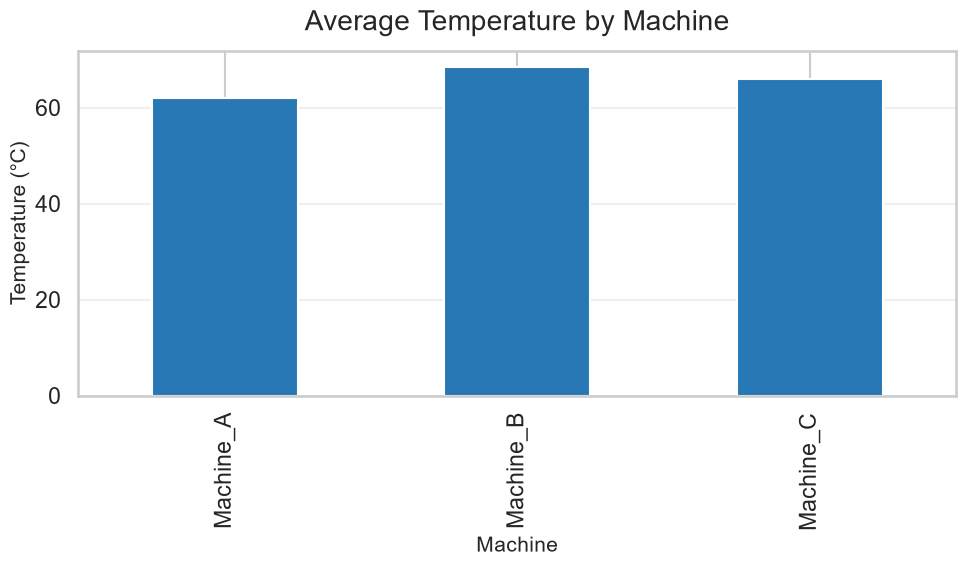

In [45]:
# Compare average temperature across machines.
average_temperature = clean_data.groupby("machine_id")["temperature"].mean()
fig, ax = plt.subplots(figsize=(10, 6))
average_temperature.plot(kind="bar", color=BLUE, ax=ax)
ax.set_title("Average Temperature by Machine", pad=15)
ax.set_xlabel("Machine")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_average_temperature_by_machine.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Machine_B has the highest average temperature, which is consistent with the gradual drift added to its readings.

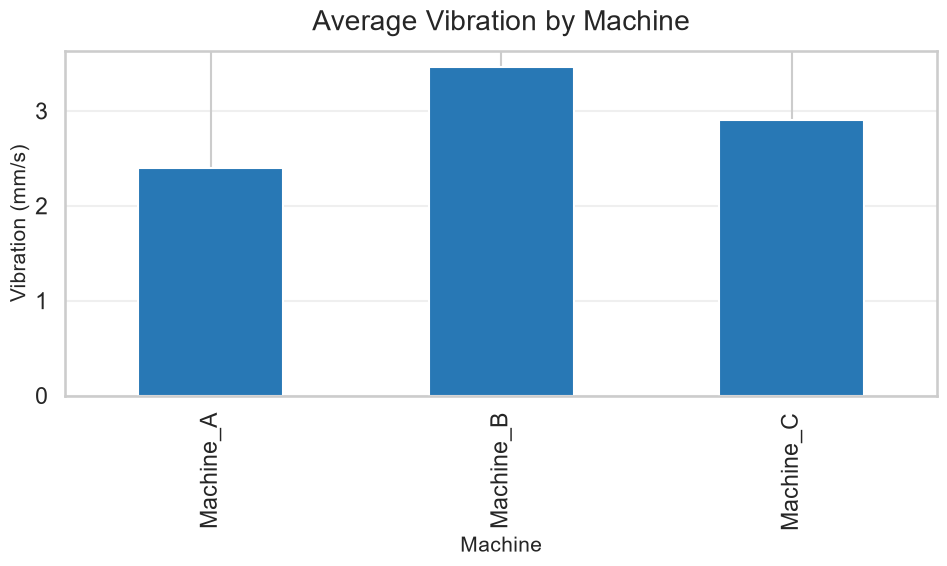

In [46]:
# Compare average vibration across machines.
average_vibration = clean_data.groupby("machine_id")["vibration"].mean()
fig, ax = plt.subplots(figsize=(10, 6))
average_vibration.plot(kind="bar", color=BLUE, ax=ax)
ax.set_title("Average Vibration by Machine", pad=15)
ax.set_xlabel("Machine")
ax.set_ylabel("Vibration (mm/s)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_average_vibration_by_machine.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Machine_B also has the highest average vibration, so both sensors point to a change worth investigating.

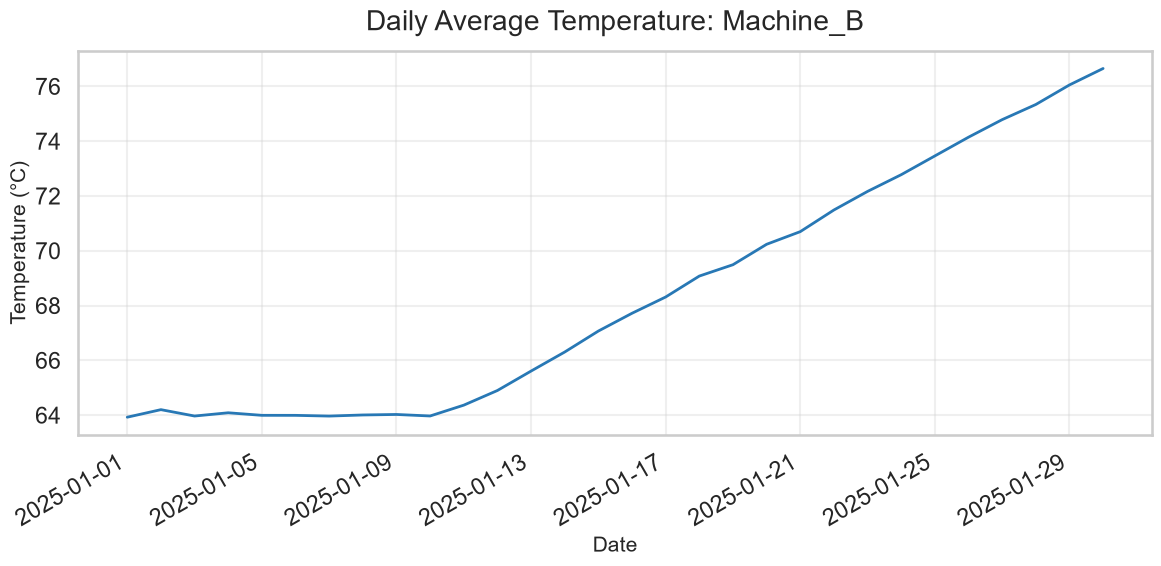

In [47]:
# Plot daily average temperature for Machine_B.
selected_machine = "Machine_B"
daily_temperature = clean_data[clean_data["machine_id"] == selected_machine].copy()
daily_temperature["day"] = daily_temperature["timestamp"].dt.floor("D")
daily_temperature = daily_temperature.groupby("day")["temperature"].mean()
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily_temperature.index, daily_temperature.values, color=BLUE, linewidth=2)
ax.set_title("Daily Average Temperature: Machine_B", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_machine_b_daily_temperature.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Machine_B's daily average temperature rises over the month, making the gradual drift visible.

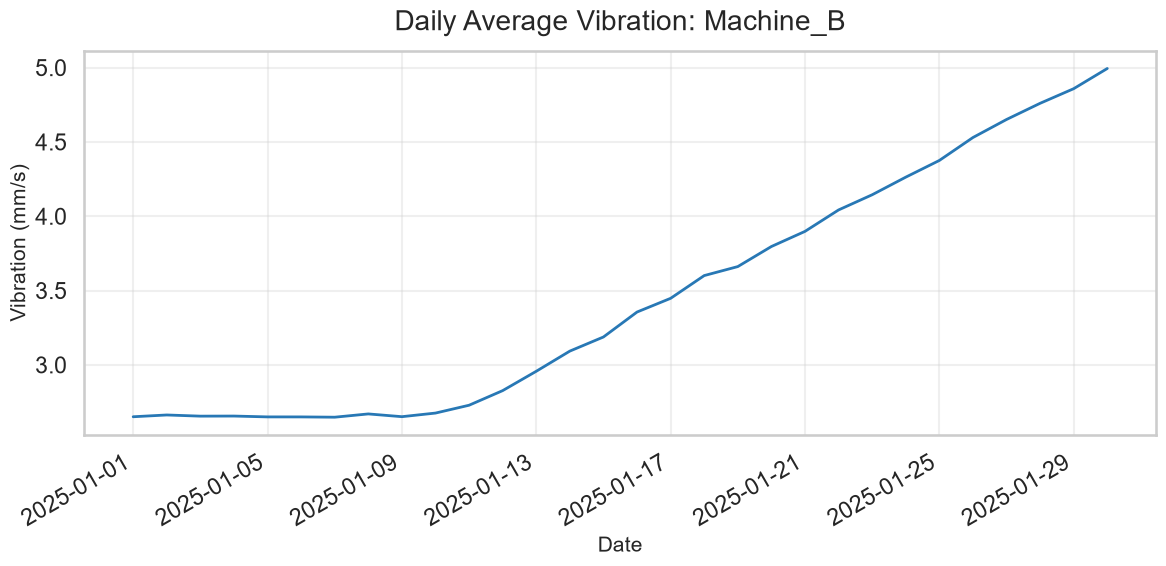

In [48]:
# Plot daily average vibration for Machine_B.
daily_vibration = clean_data[clean_data["machine_id"] == selected_machine].copy()
daily_vibration["day"] = daily_vibration["timestamp"].dt.floor("D")
daily_vibration = daily_vibration.groupby("day")["vibration"].mean()
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily_vibration.index, daily_vibration.values, color=BLUE, linewidth=2)
ax.set_title("Daily Average Vibration: Machine_B", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Vibration (mm/s)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_machine_b_daily_vibration.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Vibration also trends upward on Machine_B, supporting the temperature-based warning rather than indicating an isolated temperature effect.

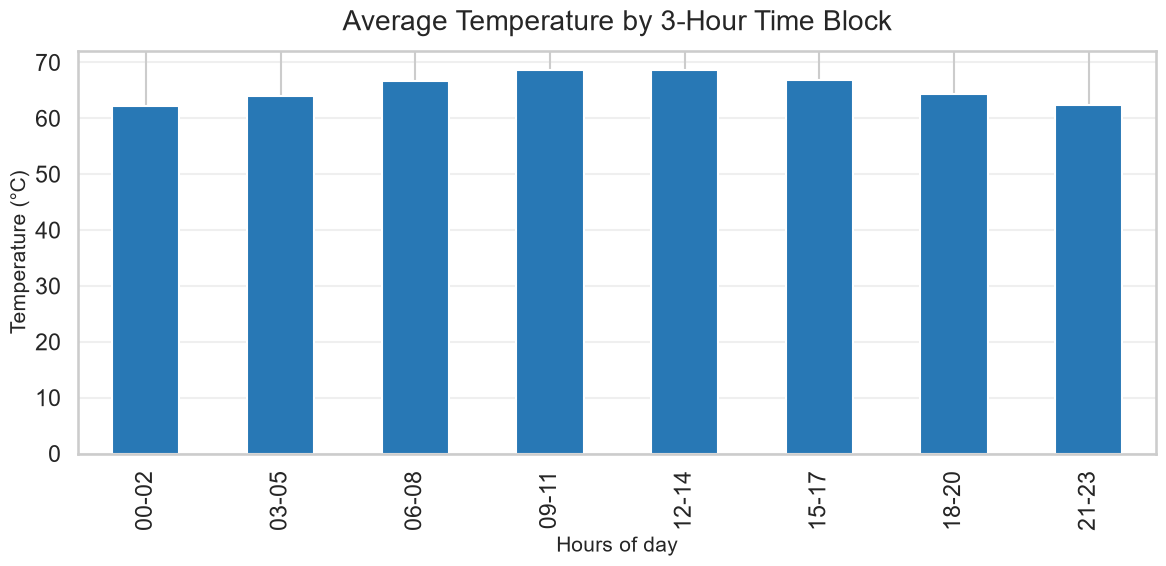

In [49]:
# Compare hourly temperatures in eight three-hour blocks for a clear bar chart.
hour_block = (clean_data["timestamp"].dt.hour // 3) * 3
hourly_temperature = clean_data.groupby(hour_block)["temperature"].mean()
hour_labels = []
for start_hour in hourly_temperature.index:
    hour_labels.append(f"{start_hour:02d}-{start_hour + 2:02d}")
hourly_temperature.index = hour_labels
fig, ax = plt.subplots(figsize=(12, 6))
hourly_temperature.plot(kind="bar", color=BLUE, ax=ax)
ax.set_title("Average Temperature by 3-Hour Time Block", pad=15)
ax.set_xlabel("Hours of day")
ax.set_ylabel("Temperature (°C)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_average_temperature_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Three-hour blocks keep the chart readable while showing the daily temperature cycle.

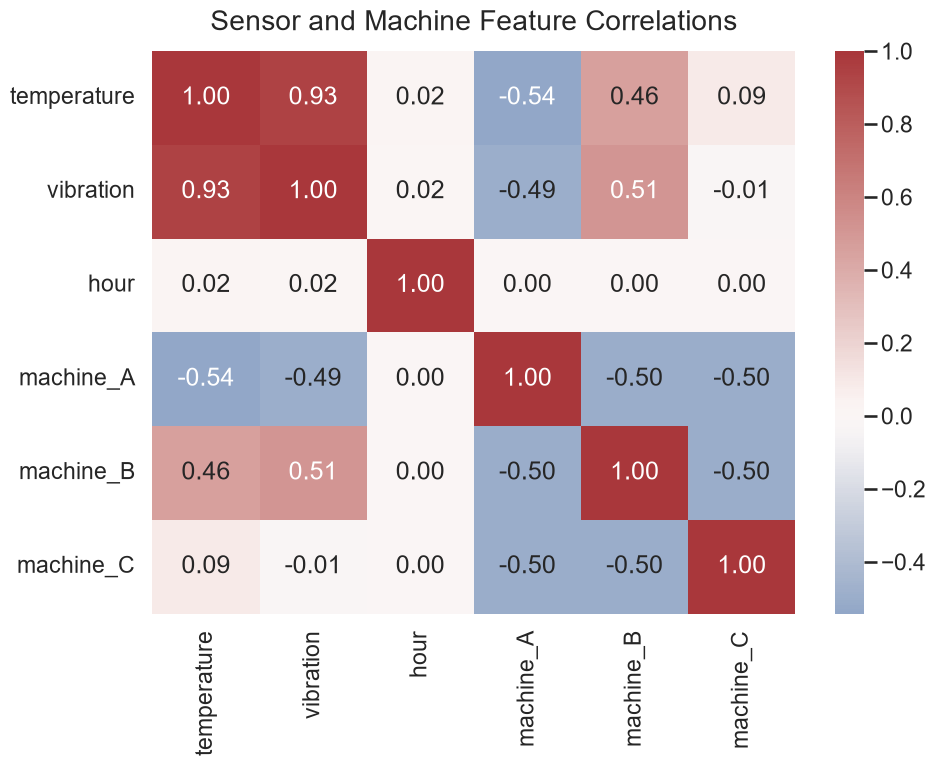

In [50]:
# Build a correlation heatmap with machine indicator features and hour.
correlation_data = clean_data[["temperature", "vibration"]].copy()
correlation_data["hour"] = clean_data["timestamp"].dt.hour
correlation_data["machine_A"] = (clean_data["machine_id"] == "Machine_A").astype(int)
correlation_data["machine_B"] = (clean_data["machine_id"] == "Machine_B").astype(int)
correlation_data["machine_C"] = (clean_data["machine_id"] == "Machine_C").astype(int)
correlation_matrix = correlation_data.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Sensor and Machine Feature Correlations", pad=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Correlations summarize relationships in this simulated sample; the heatmap alone does not prove that one sensor causes another to change.

**EDA takeaways:** Machine_B has the highest average readings, both Machine_B sensors rise over time, hourly averages expose a daily cycle, and sensor correlations should be treated as descriptive rather than causal.

## 7. Time Series Analysis and Sliding Window

A sliding window looks at a fixed number of recent readings, moves forward one reading at a time, and recalculates a summary. For example, with values `[2, 3, 4, 5]` and a window of 3, the windows are `[2, 3, 4]` and `[3, 4, 5]`; here six hours means 36 ten-minute readings.

In [67]:
# Calculate six-hour rolling means and standard deviations per machine.
WINDOW_READINGS = 6 * 6
rolling_data = clean_data.sort_values(["machine_id", "timestamp"]).copy()
for machine_name in machine_names:
    machine_mask = rolling_data["machine_id"] == machine_name
    for sensor_name in ["temperature", "vibration"]:
        sensor_values = rolling_data.loc[machine_mask, sensor_name]
        rolling_data.loc[machine_mask, sensor_name + "_rolling_mean"] = sensor_values.rolling(
            WINDOW_READINGS, min_periods=WINDOW_READINGS
        ).mean()
        rolling_data.loc[machine_mask, sensor_name + "_rolling_std"] = sensor_values.rolling(
            WINDOW_READINGS, min_periods=WINDOW_READINGS
        ).std()

# Set alert thresholds for the dashboard and sensor alerts.
warning_thresholds = {"temperature": 82.0, "vibration": 6.0}
critical_thresholds = {"temperature": 88.0, "vibration": 8.5}
print("Rolling window:", WINDOW_READINGS, "readings = 6 hours")
print("Warning thresholds:", warning_thresholds)
print("Critical thresholds:", critical_thresholds)

Rolling window: 36 readings = 6 hours
Warning thresholds: {'temperature': 82.0, 'vibration': 6.0}
Critical thresholds: {'temperature': 88.0, 'vibration': 8.5}


In [68]:
# Calculate baseline limits and flag drift and unusually large spikes.
baseline_end = rolling_data["timestamp"].min() + pd.Timedelta(days=3)
baseline_limits = {}

# Create separate flags for each sensor's drift and spikes.
for sensor_name in ["temperature", "vibration"]:
    rolling_data[sensor_name + "_drift"] = False
    rolling_data[sensor_name + "_spike"] = False
    rolling_data[sensor_name + "_spike_threshold"] = np.nan

# Compare each machine and sensor with its baseline and previous window.
for machine_name in machine_names:
    machine_mask = rolling_data["machine_id"] == machine_name
    baseline_mask = machine_mask & (rolling_data["timestamp"] < baseline_end)
    for sensor_name in ["temperature", "vibration"]:
        baseline_mean = rolling_data.loc[baseline_mask, sensor_name].mean()
        baseline_std = rolling_data.loc[baseline_mask, sensor_name].std()
        lower_limit = baseline_mean - 3 * baseline_std
        upper_limit = baseline_mean + 3 * baseline_std
        rolling_mean_name = sensor_name + "_rolling_mean"
        baseline_limits[(machine_name, sensor_name)] = (lower_limit, upper_limit)
        drift_mask = rolling_data["timestamp"] >= baseline_end
        drift_mask = machine_mask & drift_mask & (
            (rolling_data[rolling_mean_name] < lower_limit)
            | (rolling_data[rolling_mean_name] > upper_limit)
        )
        rolling_data.loc[drift_mask, sensor_name + "_drift"] = True

        machine_values = rolling_data.loc[machine_mask, sensor_name]
        z_score = (machine_values - baseline_mean) / baseline_std
        machine_drift = rolling_data.loc[machine_mask, sensor_name + "_drift"]
        spike_flags = (z_score > 3) & (~machine_drift)
        rolling_data.loc[machine_mask, sensor_name + "_spike"] = spike_flags
        rolling_data.loc[machine_mask, sensor_name + "_spike_threshold"] = baseline_mean + 3 * baseline_std

print("Baseline period ends:", baseline_end)
print("Sensor drift and spike flags are ready.")

Baseline period ends: 2025-01-04 00:00:00
Sensor drift and spike flags are ready.


The baseline is the first three days for each machine. A drift flag means its six-hour rolling mean moves outside that baseline's mean ± 3 standard deviations; a spike flag means a reading is more than three baseline standard deviations above its baseline mean, unless the rolling mean already identifies drift.

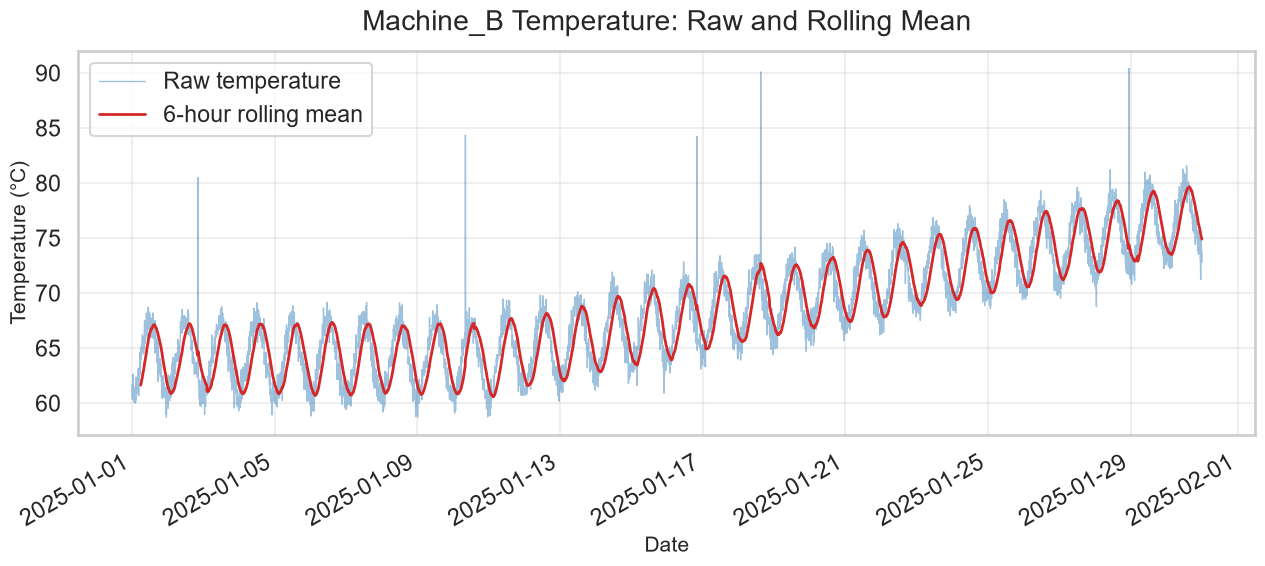

In [53]:
# Compare raw temperature with its six-hour rolling mean for Machine_B.
machine_b_data = rolling_data[rolling_data["machine_id"] == "Machine_B"]
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(machine_b_data["timestamp"], machine_b_data["temperature"], color=BLUE, alpha=0.45, linewidth=1, label="Raw temperature")
ax.plot(machine_b_data["timestamp"], machine_b_data["temperature_rolling_mean"], color=RED, linewidth=2, label="6-hour rolling mean")
ax.set_title("Machine_B Temperature: Raw and Rolling Mean", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_machine_b_rolling_temperature.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** The rolling mean smooths short-lived noise and makes Machine_B's sustained temperature increase easier to distinguish from individual spikes.

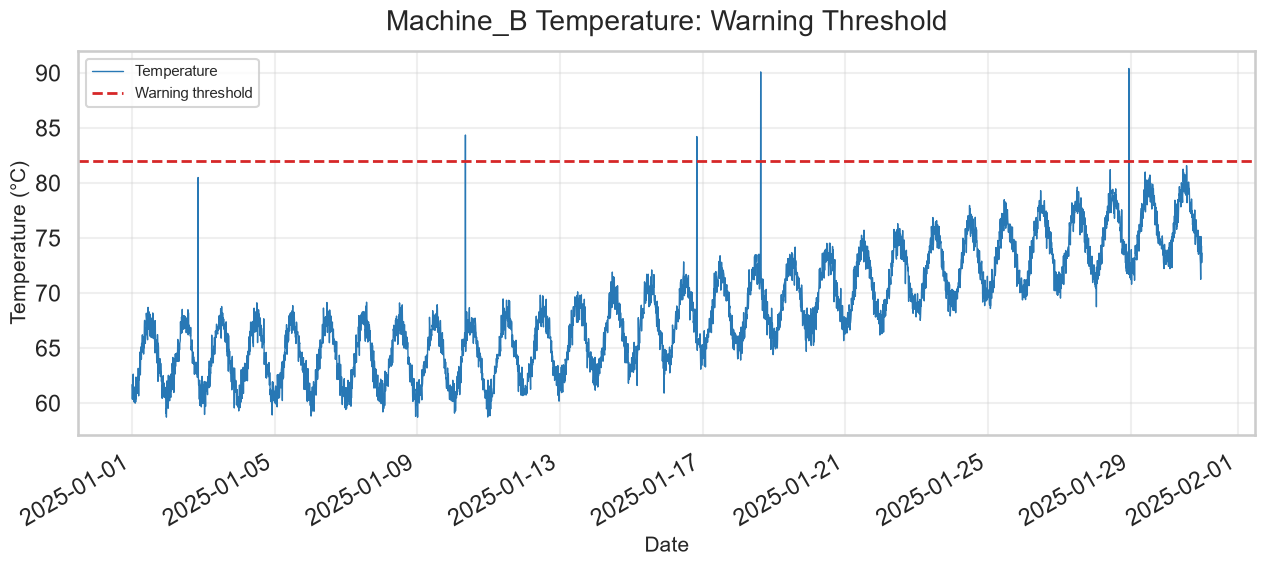

In [54]:
# Show Machine_B temperature with its warning threshold.
temperature_limits = baseline_limits[("Machine_B", "temperature")]
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(machine_b_data["timestamp"], machine_b_data["temperature"], color=BLUE, linewidth=1, label="Temperature")
ax.axhline(warning_thresholds["temperature"], color=RED, linestyle="--", linewidth=2, label="Warning threshold")
ax.set_title("Machine_B Temperature: Warning Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_temperature_warning_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** The warning line shows the early alert point; the critical limit and baseline comparison are shown separately to keep charts easy to read.

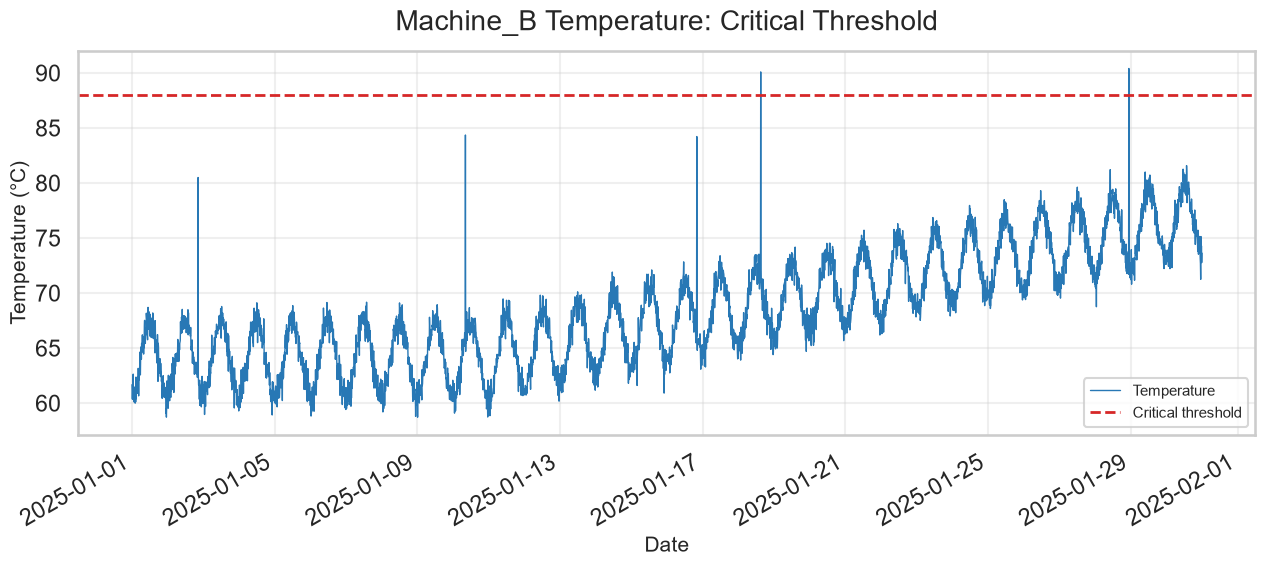

In [69]:
# Show Machine_B temperature with its critical threshold.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(machine_b_data["timestamp"], machine_b_data["temperature"], color=BLUE, linewidth=1, label="Temperature")
ax.axhline(critical_thresholds["temperature"], color=RED, linestyle="--", linewidth=2, label="Critical threshold")
ax.set_title("Machine_B Temperature: Critical Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_temperature_critical_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** The critical temperature line identifies the more urgent response level without adding another series to the chart.

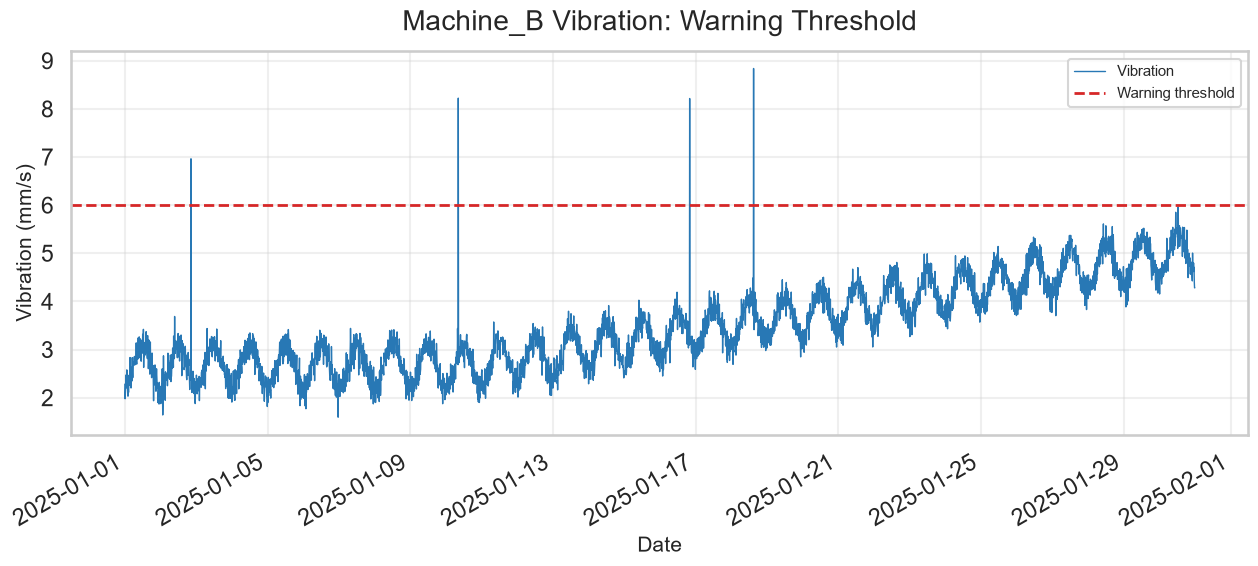

In [56]:
# Show Machine_B vibration with its warning threshold.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(machine_b_data["timestamp"], machine_b_data["vibration"], color=BLUE, linewidth=1, label="Vibration")
ax.axhline(warning_thresholds["vibration"], color=RED, linestyle="--", linewidth=2, label="Warning threshold")
ax.set_title("Machine_B Vibration: Warning Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Vibration (mm/s)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_vibration_warning_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** The vibration warning line helps reveal readings that need attention before they reach the critical level.

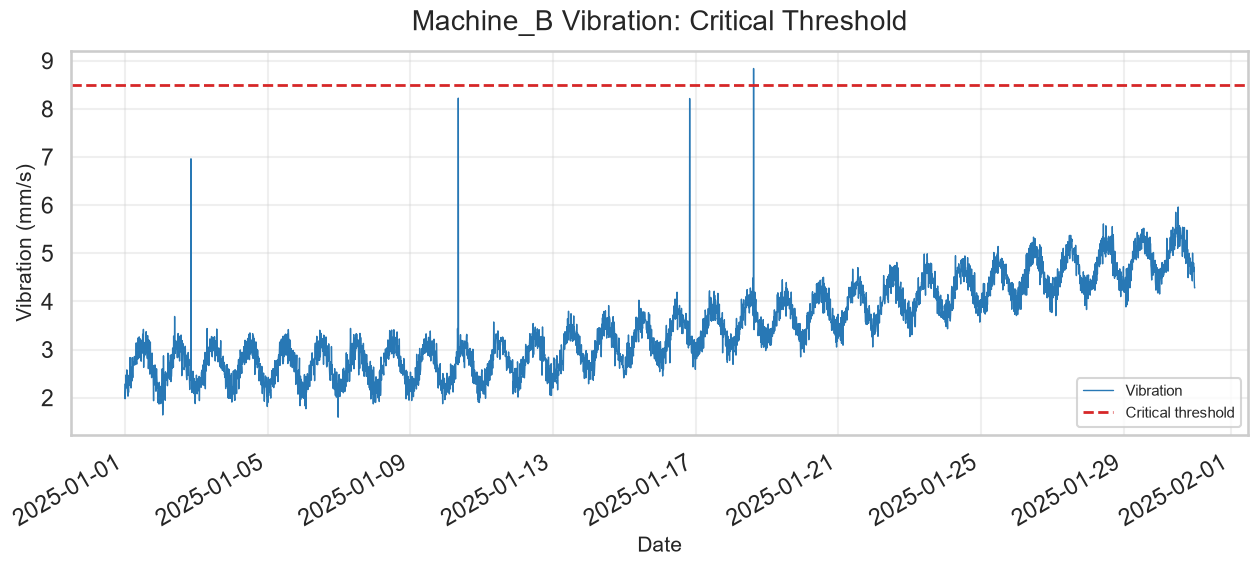

In [70]:
# Show Machine_B vibration with its critical threshold.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(machine_b_data["timestamp"], machine_b_data["vibration"], color=BLUE, linewidth=1, label="Vibration")
ax.axhline(critical_thresholds["vibration"], color=RED, linestyle="--", linewidth=2, label="Critical threshold")
ax.set_title("Machine_B Vibration: Critical Threshold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Vibration (mm/s)")
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "12_vibration_critical_threshold.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** The critical vibration line marks the highest acceptable reading before an urgent machine check is recommended.

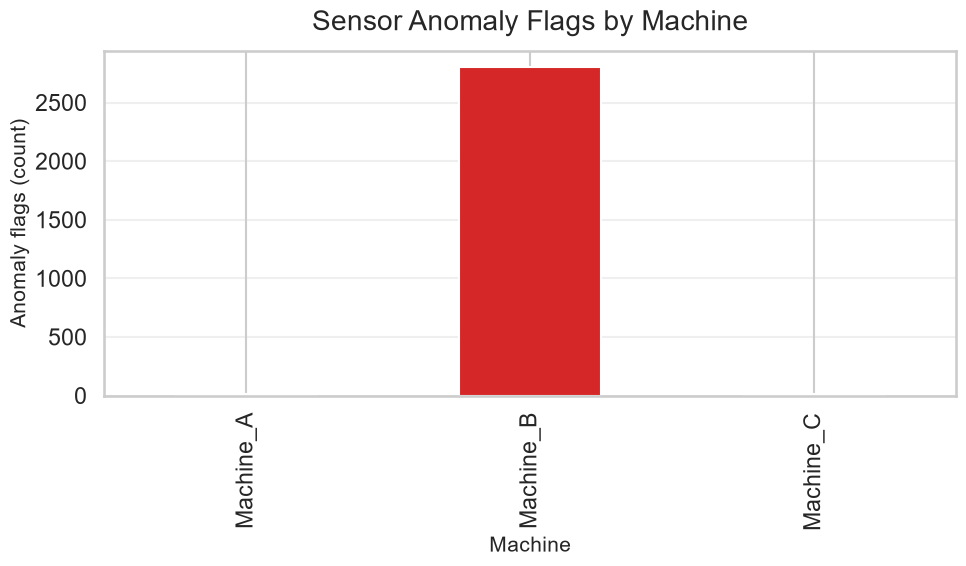

In [71]:
# Count sensor anomaly flags by machine for the first overview chart.
anomaly_counts = []
for machine_name in machine_names:
    machine_rows = rolling_data[rolling_data["machine_id"] == machine_name]
    count = int(machine_rows[["temperature_drift", "temperature_spike", "vibration_drift", "vibration_spike"]].sum().sum())
    anomaly_counts.append(count)
anomaly_by_machine = pd.Series(anomaly_counts, index=machine_names)
fig, ax = plt.subplots(figsize=(10, 6))
anomaly_by_machine.plot(kind="bar", color=RED, ax=ax)
ax.set_title("Sensor Anomaly Flags by Machine", pad=15)
ax.set_xlabel("Machine")
ax.set_ylabel("Anomaly flags (count)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "13_anomalies_by_machine.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Machine_B produces the largest number of sensor flags, driven by its intentional gradual drift.

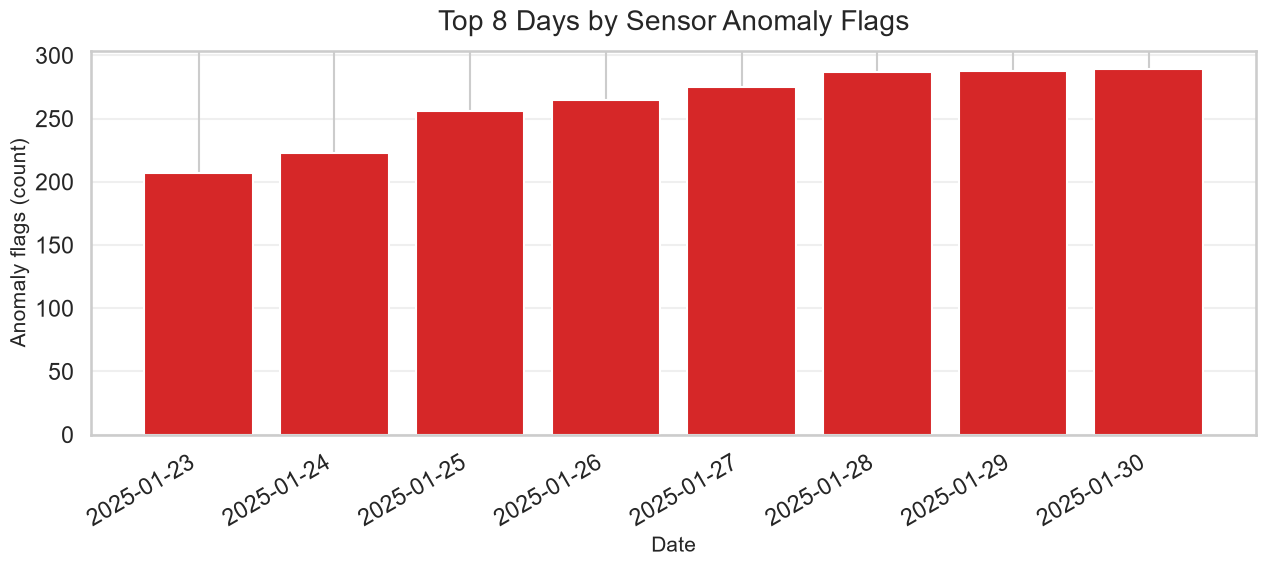

In [72]:
# Count flagged sensor readings by day.
rolling_data["day"] = rolling_data["timestamp"].dt.floor("D")
flag_columns = ["temperature_drift", "temperature_spike", "vibration_drift", "vibration_spike"]
daily_anomaly_counts = rolling_data.groupby("day")[flag_columns].sum().sum(axis=1)
top_anomaly_days = daily_anomaly_counts.nlargest(8).sort_index()
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(top_anomaly_days.index, top_anomaly_days.values, color=RED, width=0.8)
ax.set_title("Top 8 Days by Sensor Anomaly Flags", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Anomaly flags (count)")
ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "14_anomalies_by_day.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

**Insight:** Daily anomaly counts rise as the drift progresses, which is useful for showing when operational behavior begins to depart from baseline.

In [73]:
# Find the first detected drift time for each machine and sensor.
drift_start_rows = []
for machine_name in machine_names:
    machine_rows = rolling_data[rolling_data["machine_id"] == machine_name]
    for sensor_name in ["temperature", "vibration"]:
        drift_rows = machine_rows[machine_rows[sensor_name + "_drift"]]
        if len(drift_rows) > 0:
            start_time = drift_rows["timestamp"].min()
        else:
            start_time = pd.NaT
        drift_start_rows.append({
            "machine_id": machine_name,
            "sensor": sensor_name,
            "first_drift_time": start_time
        })
drift_start_table = pd.DataFrame(drift_start_rows)
display(drift_start_table)
detected_drift = drift_start_table.dropna(subset=["first_drift_time"])
if len(detected_drift) > 0:
    print("Detected drift starts:")
    display(detected_drift)
else:
    print("No drift was detected with the selected baseline and window.")

,machine_id,sensor,first_drift_time
0,Machine_A,temperature,NaT
1,Machine_A,vibration,NaT
2,Machine_B,temperature,2025-01-18 14:00:00
3,Machine_B,vibration,2025-01-18 13:30:00
4,Machine_C,temperature,NaT
5,Machine_C,vibration,NaT


Detected drift starts:


,machine_id,sensor,first_drift_time
2,Machine_B,temperature,2025-01-18 14:00:00
3,Machine_B,vibration,2025-01-18 13:30:00


## 8. Report Creation and Export

The anomaly report has one row per sensor alert, including the observed value, a comparison threshold, severity, and whether the alert is a spike or drift. A warning/critical threshold determines severity; a drift alert also records its baseline boundary.

In [74]:
# Convert sensor drift and spike flags into report rows.
report_rows = []
for row_number, row in rolling_data.iterrows():
    for sensor_name in ["temperature", "vibration"]:
        for anomaly_type in ["Drift", "Spike"]:
            flag_name = sensor_name + "_" + anomaly_type.lower()
            if row[flag_name]:
                value = float(row[sensor_name])
                warning_limit = warning_thresholds[sensor_name]
                critical_limit = critical_thresholds[sensor_name]
                if value >= critical_limit:
                    severity = "Critical"
                    threshold = critical_limit
                elif value >= warning_limit:
                    severity = "Warning"
                    threshold = warning_limit
                else:
                    severity = "Warning"
                    threshold = warning_limit
                if anomaly_type == "Drift":
                    limits = baseline_limits[(row["machine_id"], sensor_name)]
                    if value > limits[1]:
                        threshold = limits[1]
                    else:
                        threshold = limits[0]
                else:
                    threshold = row[sensor_name + "_spike_threshold"]
                report_rows.append({
                    "timestamp": row["timestamp"],
                    "machine_id": row["machine_id"],
                    "sensor": sensor_name,
                    "value": value,
                    "threshold": float(threshold),
                    "severity": severity,
                    "anomaly_type": anomaly_type
                })

# Create, sort, preview, and export the anomaly report.
report_columns = ["timestamp", "machine_id", "sensor", "value", "threshold", "severity", "anomaly_type"]
anomaly_report = pd.DataFrame(report_rows, columns=report_columns)
anomaly_report = anomaly_report.sort_values("timestamp").reset_index(drop=True)
display(anomaly_report.head(10))
anomaly_report.to_csv(OUTPUT_DIR / "anomaly_report.csv", index=False)
print("Report rows:", len(anomaly_report))
print("Saved to outputs/anomaly_report.csv")

,timestamp,machine_id,sensor,value,threshold,severity,anomaly_type
0,2025-01-02 20:30:00,Machine_B,vibration,6.963192,3.924700,Warning,Spike
1,2025-01-02 20:30:00,Machine_B,temperature,80.504375,71.997181,Warning,Spike
2,2025-01-03 08:10:00,Machine_A,temperature,81.623440,70.343931,Warning,Spike
3,2025-01-03 08:10:00,Machine_A,vibration,7.472401,3.714567,Warning,Spike
4,2025-01-08 19:20:00,Machine_A,temperature,80.109675,70.343931,Warning,Spike
5,2025-01-08 19:20:00,Machine_A,vibration,7.382111,3.714567,Warning,Spike
6,2025-01-10 08:20:00,Machine_B,vibration,8.223507,3.924700,Warning,Spike
7,2025-01-10 08:20:00,Machine_B,temperature,84.364830,71.997181,Warning,Spike
8,2025-01-11 14:10:00,Machine_C,vibration,8.459308,4.020373,Warning,Spike
9,2025-01-11 14:10:00,Machine_C,temperature,85.537693,73.840715,Warning,Spike


Report rows: 2818
Saved to outputs/anomaly_report.csv


In [75]:
# Summarize anomaly counts by machine and severity and save the table.
if len(anomaly_report) > 0:
    report_summary = anomaly_report.groupby(["machine_id", "severity"]).size().unstack(fill_value=0).reset_index()
else:
    report_summary = pd.DataFrame(columns=["machine_id", "Warning", "Critical"])
display(report_summary)
report_summary.to_csv(OUTPUT_DIR / "anomaly_summary_by_machine_severity.csv", index=False)

severity,machine_id,Critical,Warning
0,Machine_A,0,10
1,Machine_B,3,2796
2,Machine_C,0,9


## 9. Tkinter Dashboard

The dashboard opens in a separate desktop window and must be run locally in Jupyter or VS Code; it does not run in Google Colab. The next cell only defines the app, so Restart and Run All will not hang; run the final dashboard cell when you want to open it.

In [76]:
# Define a local Tkinter app with a chart, alert dots, and live KPIs.
def open_dashboard():
    import tkinter as tk
    from tkinter import messagebox
    from matplotlib.figure import Figure
    from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

    # Create a dark window and its dropdown selections.
    root = tk.Tk()
    root.title("Industry 4.0 | Sensor Monitor")
    root.geometry("1100x760")
    root.configure(bg=DARK)
    machine_choice = tk.StringVar(value=machine_names[0])
    sensor_choice = tk.StringVar(value="temperature")
    title = tk.Label(root, text="INDUSTRY 4.0  |  SENSOR MONITOR", bg=DARK, fg="white", font=("Segoe UI", 20, "bold"))
    title.pack(pady=(18, 10))

    # Create three simple KPI cards across the top.
    cards = tk.Frame(root, bg=DARK)
    cards.pack(fill="x", padx=20, pady=8)
    total_value = tk.StringVar(value="0")
    anomaly_value = tk.StringVar(value="0")
    percent_value = tk.StringVar(value="0.0%")
    card_values = [total_value, anomaly_value, percent_value]
    card_titles = ["TOTAL READINGS", "ANOMALIES FOUND", "% ANOMALOUS"]
    for card_number in range(3):
        card = tk.Frame(cards, bg="#243342", padx=20, pady=12)
        card.pack(side="left", fill="x", expand=True, padx=6)
        tk.Label(card, text=card_titles[card_number], bg="#243342", fg="#B9C7D3", font=("Segoe UI", 10, "bold")).pack()
        tk.Label(card, textvariable=card_values[card_number], bg="#243342", fg="white", font=("Segoe UI", 20, "bold")).pack(pady=4)

    # Add machine and sensor controls.
    controls = tk.Frame(root, bg=DARK)
    controls.pack(fill="x", padx=28, pady=10)
    tk.Label(controls, text="Machine", bg=DARK, fg="white", font=("Segoe UI", 11)).pack(side="left", padx=(0, 8))
    machine_menu = tk.OptionMenu(controls, machine_choice, *machine_names)
    machine_menu.config(bg="#243342", fg="white", activebackground="#34495E", highlightthickness=0)
    machine_menu.pack(side="left", padx=(0, 22))
    tk.Label(controls, text="Sensor", bg=DARK, fg="white", font=("Segoe UI", 11)).pack(side="left", padx=(0, 8))
    sensor_menu = tk.OptionMenu(controls, sensor_choice, "temperature", "vibration")
    sensor_menu.config(bg="#243342", fg="white", activebackground="#34495E", highlightthickness=0)
    sensor_menu.pack(side="left")

    # Create a chart area that will be refreshed when selections change.
    chart_area = tk.Frame(root, bg="white")
    chart_area.pack(fill="both", expand=True, padx=20, pady=10)
    canvas_holder = {"canvas": None}

    # Draw the selected sensor and highlight its reported anomalies.
    def render_chart(*args):
        machine_name = machine_choice.get()
        sensor_name = sensor_choice.get()
        selected = rolling_data[rolling_data["machine_id"] == machine_name]
        selected_report = anomaly_report[
            (anomaly_report["machine_id"] == machine_name)
            & (anomaly_report["sensor"] == sensor_name)
        ]
        reading_count = len(selected)
        anomaly_count = selected_report["timestamp"].nunique()
        total_value.set(str(reading_count))
        anomaly_value.set(str(anomaly_count))
        if reading_count > 0:
            percent_value.set(f"{100 * anomaly_count / reading_count:.1f}%")
        else:
            percent_value.set("0.0%")

        # Replace the old embedded chart with the newly selected chart.
        if canvas_holder["canvas"] is not None:
            canvas_holder["canvas"].get_tk_widget().destroy()
        figure = Figure(figsize=(10, 5), dpi=100, facecolor="white")
        axis = figure.add_subplot(111)
        axis.plot(selected["timestamp"], selected[sensor_name], color=BLUE, linewidth=1, label=sensor_name.title())
        axis.axhline(warning_thresholds[sensor_name], color=RED, linestyle="--", label="Warning threshold")
        axis.axhline(critical_thresholds[sensor_name], color=RED, linestyle=":", label="Critical threshold")
        if len(selected_report) > 0:
            axis.scatter(selected_report["timestamp"], selected_report["value"], color=RED, s=28, label="Anomaly", zorder=3)
        axis.set_title(machine_name + " | " + sensor_name.title(), fontsize=15)
        axis.set_xlabel("Timestamp")
        if sensor_name == "temperature":
            axis.set_ylabel("Temperature (°C)")
        else:
            axis.set_ylabel("Vibration (mm/s)")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=9)
        figure.autofmt_xdate()
        figure.tight_layout()
        canvas = FigureCanvasTkAgg(figure, master=chart_area)
        canvas.draw()
        canvas.get_tk_widget().pack(fill="both", expand=True)
        canvas_holder["canvas"] = canvas

    # Export the report and show a confirmation message.
    def export_report():
        report_path = OUTPUT_DIR / "anomaly_report.csv"
        anomaly_report.to_csv(report_path, index=False)
        messagebox.showinfo("Report exported", "Anomaly report saved to:\n" + str(report_path.resolve()))

    # Connect the controls and export button to their actions.
    machine_choice.trace_add("write", render_chart)
    sensor_choice.trace_add("write", render_chart)
    export_button = tk.Button(controls, text="Export Report", command=export_report, bg=RED, fg="white", font=("Segoe UI", 10, "bold"), relief="flat", padx=12, pady=7)
    export_button.pack(side="right")
    render_chart()
    root.mainloop()

To launch the app locally, change `RUN_DASHBOARD` to `True` and run this cell. Close the window to return to the notebook; leaving the default `False` lets Restart and Run All finish without opening a window.

In [ ]:
# Set this to True when you want to open the local dashboard.
RUN_DASHBOARD = True
if RUN_DASHBOARD:
    open_dashboard()

## 10. Conclusion

**Key takeaways**
- The generated dataset contains three machines with ten-minute temperature and vibration readings over 30 days.
- Cleaning removed duplicate machine/timestamp records and interpolated missing sensor values within each machine.
- Six-hour rolling windows reduced short-term noise and compared behavior with each machine's first three days.
- The simulated Machine_B drift appears in both temperature and vibration, alongside individual spike alerts.
- The exported report and local dashboard provide a starting point for reviewing alerts, not a substitute for engineering validation.

**Recommendations**
1. Inspect Machine_B and verify its sensor calibration and operating conditions, especially after the first detected drift time.
2. Establish machine-specific alert limits from validated operating data and have maintenance staff review persistent warnings.
3. Keep the raw readings and anomaly report for traceability, and test these rules against real machine data before production use.

**Files in `outputs/`**
The code below lists all files produced when the notebook cells have run.

In [78]:
# List every generated file in the outputs folder.
for output_file in sorted(OUTPUT_DIR.iterdir()):
    print(output_file.name)

01_missing_values.png
02_average_temperature_by_machine.png
03_average_vibration_by_machine.png
04_machine_b_daily_temperature.png
05_machine_b_daily_vibration.png
06_average_temperature_by_hour.png
07_correlation_heatmap.png
08_machine_b_rolling_temperature.png
09_temperature_warning_threshold.png
10_temperature_critical_threshold.png
11_vibration_warning_threshold.png
12_vibration_critical_threshold.png
13_anomalies_by_machine.png
14_anomalies_by_day.png
anomaly_report.csv
anomaly_summary_by_machine_severity.csv
data_quality_comparison.csv
machine_summary.csv
sensor_readings_raw.csv
